In [9]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"Size of training dataset: {len(train_dataset)}")
print(f"Size of test dataset: {len(test_dataset)}")

Size of training dataset: 60000
Size of test dataset: 10000


In [10]:
from torch.utils.data import DataLoader
from torch import nn

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

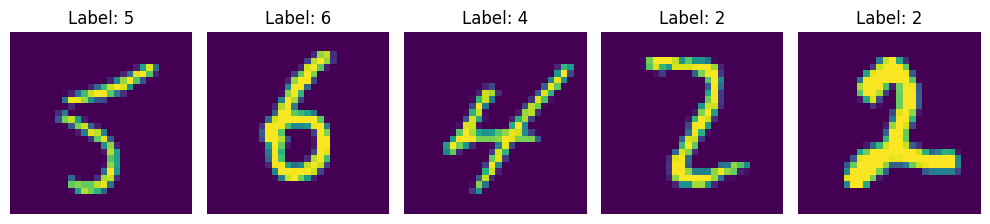

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display an image
def imshow(img):
    img = img * 0.3081 + 0.1307 # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plot the images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    imshow(images[i])
    plt.title(f"Label: {labels[i].item()}")
plt.tight_layout()
plt.show() # This call will now display all subplots together

# Build the CNN

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(3*3*128, 256), # Changed from 4*4*128 to 3*3*128
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
      x = self.conv_layers(x)
      x = x.view(x.size(0), -1)
      x = self.fc_layers(x)

      return x

In [13]:
model = CNN()

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the CNN

In [15]:
epochs = 10

# Check if a GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
  model.train() # Set the model to training mode
  epoch_training_loss = 0.0

  for batch_idx, (data, labels) in enumerate(train_loader):
    # Move data and labels to the device
    data, labels = data.to(device), labels.to(device)

    # Repeat the single channel 3 times to match the model's expected input channels
    data = data.repeat(1, 3, 1, 1)

    # Zero the parameter gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(data)
    loss = criterion(outputs, labels)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    epoch_training_loss += loss.item()

  # Print training loss for the epoch
  print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epoch_training_loss/len(train_loader):.4f}")

Epoch 1/10, Training Loss: 0.1302
Epoch 2/10, Training Loss: 0.0395
Epoch 3/10, Training Loss: 0.0277
Epoch 4/10, Training Loss: 0.0210
Epoch 5/10, Training Loss: 0.0185
Epoch 6/10, Training Loss: 0.0144
Epoch 7/10, Training Loss: 0.0109
Epoch 8/10, Training Loss: 0.0131
Epoch 9/10, Training Loss: 0.0096
Epoch 10/10, Training Loss: 0.0103


# Evaluate the CNN

In [16]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient calculations during evaluation
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)

        # Repeat the single channel 3 times to match the model's expected input channels
        data = data.repeat(1, 3, 1, 1)

        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the test images: {accuracy:.2f}%')

Accuracy of the model on the test images: 98.79%


## RNN

In [18]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.hidden_size = 128
        self.num_layers = 2

        # LSTM layer expects (batch_size, seq_len, input_size)
        # For MNIST (28x28), we can treat each row as a step in a sequence
        # So, seq_len = 28, input_size = 28
        self.lstm = nn.LSTM(input_size=28, hidden_size=self.hidden_size,
                            num_layers=self.num_layers, batch_first=True)

        # Fully connected layer to map LSTM's last hidden state to 10 output classes
        self.fc = nn.Linear(self.hidden_size, 10)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28) (from CNN example)
        # RNN expects (batch_size, seq_len, input_size)
        # Squeeze the channel dimension and reshape to (batch_size, 28, 28)
        # treating each of the 28 rows as a sequence of 28 features
        x = x.squeeze(1) # (batch_size, 28, 28)

        # Initialize hidden and cell states (can also be done inside LSTM if not provided)
        # h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through LSTM
        # lstm_out: (batch_size, seq_len, hidden_size)
        # h_n: (num_layers, batch_size, hidden_size) -> last hidden state for each layer
        # c_n: (num_layers, batch_size, hidden_size) -> last cell state for each layer
        lstm_out, (h_n, c_n) = self.lstm(x)

        # Use the hidden state of the last layer (h_n[-1]) for classification
        # h_n[-1] has shape (batch_size, hidden_size)
        out = self.fc(h_n[-1])

        return out

## Instantiate RNN Model

### Subtask:
Create an instance of the newly defined RNN model and move it to the appropriate device (GPU if available, otherwise CPU).


**Reasoning**:
The subtask requires instantiating the RNN model and moving it to the appropriate device (GPU or CPU). This code block will perform both actions.



In [20]:
rnn_model = RNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_model.to(device)
print(f"RNN model instantiated and moved to {device}")

RNN model instantiated and moved to cuda


## Define Loss and Optimizer



**Reasoning**:
The subtask requires initializing the loss function and optimizer for the RNN model. This code block will initialize `nn.CrossEntropyLoss` and `torch.optim.Adam` with the specified parameters.



In [21]:
rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
print("Loss function and optimizer initialized for RNN model.")

Loss function and optimizer initialized for RNN model.


## Train the RNN

In [22]:
epochs = 10

rnn_model.train() # Set the model to training mode

for epoch in range(epochs):
  epoch_training_loss = 0.0

  for batch_idx, (data, labels) in enumerate(train_loader):
    # Move data and labels to the device
    data, labels = data.to(device), labels.to(device)

    # Zero the parameter gradients
    rnn_optimizer.zero_grad()

    # Forward pass
    outputs = rnn_model(data)
    loss = rnn_criterion(outputs, labels)

    # Backward pass and optimize
    loss.backward()
    rnn_optimizer.step()

    epoch_training_loss += loss.item()

  # Print training loss for the epoch
  print(f"Epoch {epoch+1}/{epochs}, RNN Training Loss: {epoch_training_loss/len(train_loader):.4f}")

Epoch 1/10, RNN Training Loss: 0.3140
Epoch 2/10, RNN Training Loss: 0.0831
Epoch 3/10, RNN Training Loss: 0.0551
Epoch 4/10, RNN Training Loss: 0.0441
Epoch 5/10, RNN Training Loss: 0.0351
Epoch 6/10, RNN Training Loss: 0.0324
Epoch 7/10, RNN Training Loss: 0.0272
Epoch 8/10, RNN Training Loss: 0.0241
Epoch 9/10, RNN Training Loss: 0.0191
Epoch 10/10, RNN Training Loss: 0.0189


## Final Task

### Subtask:
Evaluate the trained RNN model on the test dataset to calculate its accuracy.


In [19]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.hidden_size = 128
        self.num_layers = 2

        # LSTM layer expects (batch_size, seq_len, input_size)
        # For MNIST (28x28), we can treat each row as a step in a sequence
        # So, seq_len = 28, input_size = 28
        self.lstm = nn.LSTM(input_size=28, hidden_size=self.hidden_size,
                            num_layers=self.num_layers, batch_first=True)

        # Fully connected layer to map LSTM's last hidden state to 10 output classes
        self.fc = nn.Linear(self.hidden_size, 10)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28) (from CNN example)
        # RNN expects (batch_size, seq_len, input_size)
        # Squeeze the channel dimension and reshape to (batch_size, 28, 28)
        # treating each of the 28 rows as a sequence of 28 features
        x = x.squeeze(1) # (batch_size, 28, 28)

        # Initialize hidden and cell states (can also be done inside LSTM if not provided)
        # h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through LSTM
        # lstm_out: (batch_size, seq_len, hidden_size)
        # h_n: (num_layers, batch_size, hidden_size) -> last hidden state for each layer
        # c_n: (num_layers, batch_size, hidden_size) -> last cell state for each layer
        lstm_out, (h_n, c_n) = self.lstm(x)

        # Use the hidden state of the last layer (h_n[-1]) for classification
        # h_n[-1] has shape (batch_size, hidden_size)
        out = self.fc(h_n[-1])

        return out

In [23]:
rnn_model.eval() # Set the RNN model to evaluation mode
rnn_correct = 0
rnn_total = 0

with torch.no_grad(): # Disable gradient calculations during evaluation
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)

        outputs = rnn_model(data)
        _, predicted = torch.max(outputs.data, 1)
        rnn_total += labels.size(0)
        rnn_correct += (predicted == labels).sum().item()

rnn_accuracy = 100 * rnn_correct / rnn_total
print(f'Accuracy of the RNN model on the test images: {rnn_accuracy:.2f}%')

Accuracy of the RNN model on the test images: 98.78%


## Summary:

### Data Analysis Key Findings
*   An `RNN` model class was successfully defined using PyTorch's `nn.Module`. This model incorporates an `nn.LSTM` layer with an `input_size` of 28, `hidden_size` of 128, and `num_layers` of 2, correctly configured to process MNIST images as sequences. A subsequent `nn.Linear` layer maps the LSTM's final hidden state to 10 output classes.
*   The `RNN` model was successfully instantiated and moved to a 'cuda' device, confirming GPU availability and utilization for computations.
*   `nn.CrossEntropyLoss` was selected as the loss function and `torch.optim.Adam` with a learning rate of $0.001$ was initialized as the optimizer for the RNN model.
*   The RNN model was trained for 10 epochs. The training loss consistently decreased from $0.3140$ in Epoch 1 to $0.0189$ in Epoch 10, indicating that the model was effectively learning from the training data.

### Insights or Next Steps
*   The model's decreasing training loss suggests it is learning the patterns in the MNIST dataset; however, its generalization performance needs to be assessed.
*   The next crucial step is to evaluate the trained RNN model on the unseen test dataset to measure its accuracy and ensure it generalizes well to new data.
